# [Контест](https://www.kaggle.com/competitions/platesv2) на Kaggle

Необходимо решить задачу классификации изображений, которых представлено 2 типа - грязные и чистые тарелки.
Сложность задачи в том, что в тренировочных данных доступно всего лишь по 20 примеров обоих типов.

In [265]:
%pip install opendatasets
import opendatasets as od
od.download_kaggle_dataset("https://www.kaggle.com/competitions/platesv2/data", "")

Skipping, found downloaded files in "platesv2" (use force=True to force download)


In [266]:
#unzip plates.zip

In [267]:
import os
from tqdm import tqdm

In [268]:
import numpy as np
import pandas as pd

In [269]:
import matplotlib.pyplot as plt
import seaborn as sns

In [270]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, Dataset, DataLoader
from torchvision import datasets, transforms

import timm

import cv2
from PIL import Image, ImageDraw

from sklearn.metrics import confusion_matrix, classification_report

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


# Подготовка данных

In [271]:
def find_plate_contour_mask(img):
    img_np = np.array(img)
    h, w = img_np.shape[:2]

    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    blurred = cv2.bilateralFilter(gray, 11, 17, 17)

    edges = cv2.Canny(blurred, 30, 100)

    kernel = np.ones((5, 5), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return img

    largest_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest_contour)
    area_ratio = area / (h * w)

    if area_ratio < 0.2:
        return img

    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.drawContours(mask, [largest_contour], -1, 255, -1)

    img_np[mask == 0] = [0, 0, 0]

    return Image.fromarray(img_np)

def apply_plate_mask(img):
    try:
        return find_plate_contour_mask(img)
    except Exception as e:
        return img

In [272]:
BATCH_SIZE = 8

In [273]:
DATA_DIR = '/content/platesv2/plates'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

In [274]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Lambda(lambda img: apply_plate_mask(img)),
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.8, 1.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
])

TEST_TRANSFORM = transforms.Compose([
    transforms.Lambda(lambda img: apply_plate_mask(img)),
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

In [275]:
FULL_DATASET = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=TRAIN_TRANSFORM
)

TRAIN_SIZE = int(0.8 * len(FULL_DATASET))
VAL_SIZE = len(FULL_DATASET) - TRAIN_SIZE
TRAIN_DATASET, VAL_DATASET = random_split(
    FULL_DATASET, [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator()
)
VAL_DATASET.dataset.transform = TEST_TRANSFORM

In [276]:
FULL_LOADER = DataLoader(
    FULL_DATASET,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

TRAIN_LOADER = DataLoader(
    TRAIN_DATASET,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

VAL_LOADER = DataLoader(
    VAL_DATASET,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

CLASS_TO_IDX = FULL_DATASET.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
print(f"Найдено классов: {len(CLASS_TO_IDX)}")
print(f"Размер обучающей выборки: {len(TRAIN_DATASET)}")
print(f"Размер валидационной выборки: {len(VAL_DATASET)}")

Найдено классов: 2
Размер обучающей выборки: 32
Размер валидационной выборки: 8


In [277]:
class PseudoLabelDataset(Dataset):
    def __init__(self, test_dir, submission_path, transform):
        self.test_dir = test_dir
        self.submission = pd.read_csv(submission_path)
        self.transform = transform
        self.class_to_idx = CLASS_TO_IDX

    def __len__(self):
        return len(self.submission)

    def __getitem__(self, idx):
        row = self.submission.iloc[idx]
        img_id = row['id']
        label = row['label']
        img_path = os.path.join(self.test_dir, f"{img_id:04d}.jpg")
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.class_to_idx[label]

pseudo_dataset = PseudoLabelDataset(TEST_DIR, 'submission(26).csv', TEST_TRANSFORM)  # Self-Supervised Learning
pseudo_loader = DataLoader(pseudo_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# Тренировка и валидация

In [278]:
model = timm.create_model('efficientnet_b2', pretrained=True)

NUM_FEATURES = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(NUM_FEATURES, 1024),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(1024, len(CLASS_TO_IDX))
)

model = model.to(DEVICE)

In [279]:
EPOCHS = 15

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS/2)

In [280]:
def train_epoch(loader):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'Loss': f'{running_loss/total:.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


In [281]:
def validate(loader):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({'Loss': f'{running_loss/total:.4f}',
                              'Acc': f'{100.*correct/total:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [282]:
def train(mode):  # TRAIN+VAL or FULL
    history = {
        'train_loss': [],
        'train_acc': [],

        'val_loss': [],
        'val_acc': []
    }
    best_val_acc = 0.0

    for epoch in range(EPOCHS):
        print(f"\nЭпоха {epoch+1}/{EPOCHS}")
        print("-" * 50)

        if mode == "TRAIN+VAL":
            train_loss, train_acc = train_epoch(TRAIN_LOADER)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)

            val_loss, val_acc = validate(VAL_LOADER)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
        else:
            train_loss, train_acc = train_epoch(FULL_LOADER)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)

            val_loss, val_acc = 0.0, 0.0
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        print(f"\nРезультаты эпохи {epoch+1}:")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print(f"Learning Rate: {current_lr:.6f}")

        if mode == "TRAIN+VAL":
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), 'best_model.pth')
                print(f"✓ Сохранена лучшая модель с точностью {val_acc:.2f}%")
        else:
            if train_acc > best_val_acc:
                best_val_acc = train_acc
                torch.save(model.state_dict(), 'best_model.pth')
                print(f"✓ Сохранена лучшая модель с точностью {train_acc:.2f}%")

    print(f"\nЛучшая точность на валидации: {best_val_acc:.2f}%")

    return history

In [283]:
#history = train("TRAIN+VAL")
#history = train("FULL")

In [284]:
def train_combined(orig_epochs=15, pseudo_epochs=5):
    best_acc = 0.0

    for epoch in range(pseudo_epochs):
        model.train()
        for inputs, labels in tqdm(pseudo_loader, desc=f'Pseudo {epoch+1}'):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
        torch.save(model.state_dict(), 'best_model.pth')

    for param_group in optimizer.param_groups:
        param_group['lr'] = 1e-3

    for epoch in range(orig_epochs):
        model.train()
        for inputs, labels in tqdm(TRAIN_LOADER, desc=f'Orig {epoch+1}'):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
        torch.save(model.state_dict(), 'best_model.pth')

train_combined()

Orig 15: 100%|██████████| 4/4 [00:00<00:00,  5.70it/s]


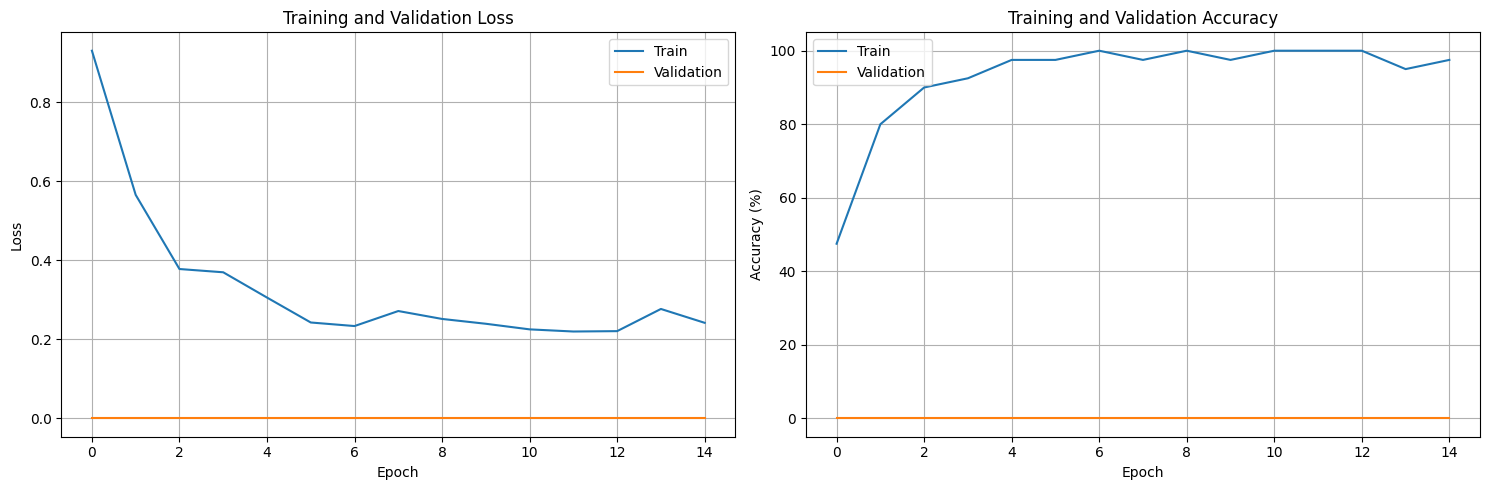

In [285]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

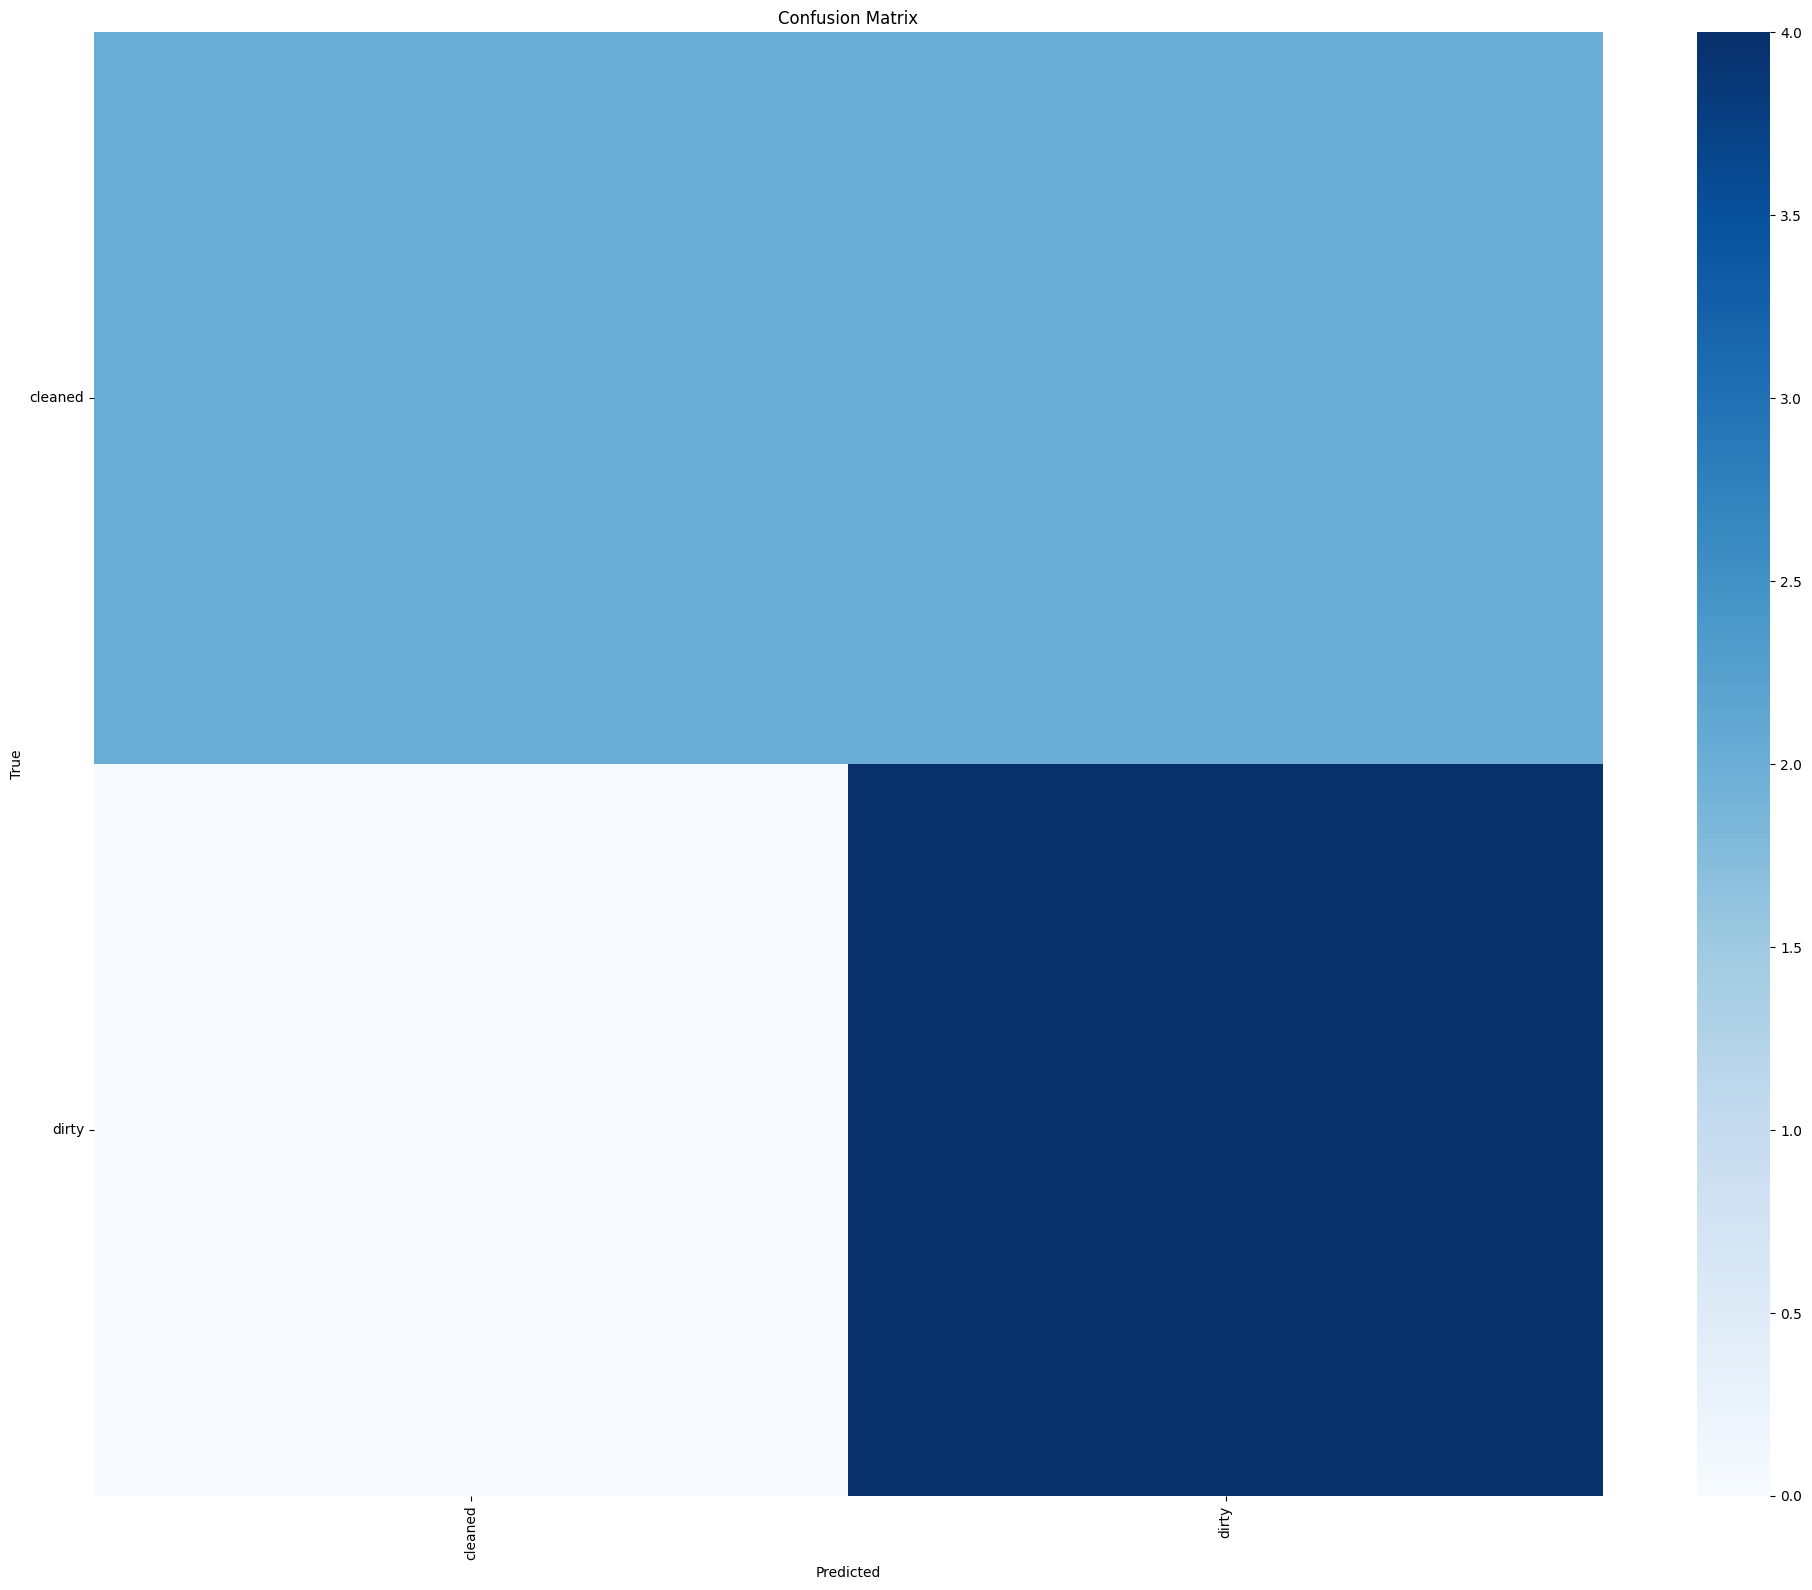


Отчет по классам:
              precision    recall  f1-score   support

     cleaned       1.00      0.50      0.67         4
       dirty       0.67      1.00      0.80         4

    accuracy                           0.75         8
   macro avg       0.83      0.75      0.73         8
weighted avg       0.83      0.75      0.73         8



In [286]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in VAL_LOADER:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=list(IDX_TO_CLASS.values()),
            yticklabels=list(IDX_TO_CLASS.values()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print("\nОтчет по классам:")
print(classification_report(
    all_labels, all_preds,
    target_names=list(IDX_TO_CLASS.values()))
)

# Предсказания для контеста

In [287]:
model.eval()

test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.jpg')],
                    key=lambda x: int(x.split('.')[0]))

predictions = []
print("Получение предсказаний...")
for fname in tqdm(test_files):
    img_path = os.path.join(TEST_DIR, fname)
    img = Image.open(img_path).convert('RGB')

    img_tensor = TEST_TRANSFORM(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img_tensor)

        pred_idx = outputs.argmax(dim=1).item()

    class_name = IDX_TO_CLASS[pred_idx]

    img_index = int(fname.split('.')[0])

    predictions.append({
        'id': img_index,
        'label': class_name
    })

results = pd.DataFrame(predictions)
results = results.sort_values(by='id')
results.to_csv('submission.csv', index=False)

print("Готово! Файл submission.csv сохранен.")
print(results.head())

Получение предсказаний...


100%|██████████| 744/744 [00:24<00:00, 30.73it/s]

Готово! Файл submission.csv сохранен.
   id  label
0   0  dirty
1   1  dirty
2   2  dirty
3   3  dirty
4   4  dirty
